# Predictive Analysis 3rd Assignment 
###  2022170841 최정우

## Introduction

현대 공급망 관리(Supply Chain Management, SCM)에서 **수요 예측(Demand Forecasting)**은 재고 비용 최소화와 서비스 수준 극대화라는 두 마리 토끼를 잡기 위한 핵심 요소입니다. 특히 물류 배송 데이터는 기업의 활동성을 직접적으로 나타내는 지표로, 정확한 예측은 효율적인 자원 배분과 운영 스케줄링의 근거가 됩니다.

2020년부터 2025년까지의 실제 공급망 인도(delivery) 데이터를 분석하여, 복잡한 패턴을 가진 시계열 데이터에 최적화된 예측 모델을 구축하는 데 있습니다. 단순 통계 모델부터 계절성을 반영한 고급 시계열 모델까지 다양한 방법론을 비교하여, 향후 10시점 이상의 수요를 가장 정확하게 예측할 수 있는 모델을 제안하고자 합니다.

## Dataset description + Target

본 분석에 사용된 데이터셋(supply_chain_deliveries.csv)은 2020년 1월부터 2025년 6월까지 약 5년 6개월간의 공급망 물동량 정보를 담고 있습니다.

관측 기간: 2020-01-02 ~ 2025-06-30

주요 변수: * WorkDate: 인도 발생 일자

Customer: 주요 고객사 (Amazon, Costco, Home Depot 등)

Location: 거점 위치 (Chicago, Los Angeles 등)

OrderCount: 발생한 주문의 수량

TotalRevenue: 해당 인도를 통해 발생한 총 매출액

핵심 예측 대상(Target Variable)은 **'월간 총 주문수(Monthly Total OrderCount)'**입니다.
일별 데이터는 변동성이 크고 불규칙한 노이즈가 많으므로, 전략적 의사결정에 적합한 월별(Monthly) 단위로 데이터를 리샘플링하여 분석을 수행합니다. 데이터의 수준(Level)이 높아짐에 따라 변동폭이 커지는 이분산성 유무를 판단하여, 필요시 로그 변환(Log Transformation)을 적용한 뒤 모델링을 진행합니다.

## Proposed Modeling Approach

예측 성능의 객관적인 비교를 위해 다음과 같이 단계별 모델링을 수행합니다.  
기초 모델: * Binary Variable Method: 월별 더미 변수를 활용한 계절성 모사  
Trigonometric Method: 삼각함수(Sin, Cos)를 이용한 주기성 모델링  
지수 평활법 (Exponential Smoothing): * Simple (SES) 및 Double Exponential Smoothing (DES)을 통한 추세 반영 확인  
Holt-Winters (Additive/Multiplicative): 가중치 파라미터($\alpha, \beta, \gamma$) 튜닝을 통한 추세 및 계절성 통합 모델링  
확률 통계 모델: * Seasonal ARIMA (SARIMA): 자기회귀 및 이동평균 기반의 정교한 시계열 모델링  

최종적으로 각 모델별로 최소 10시점 이상의 외삽(Extrapolation) 예측을 수행하고, **RMSE(Root Mean Squared Error)**와 MAPE(Mean Absolute Percentage Error) 지표를 활용하여 예측력을 평가할 예정입니다.

# EDA

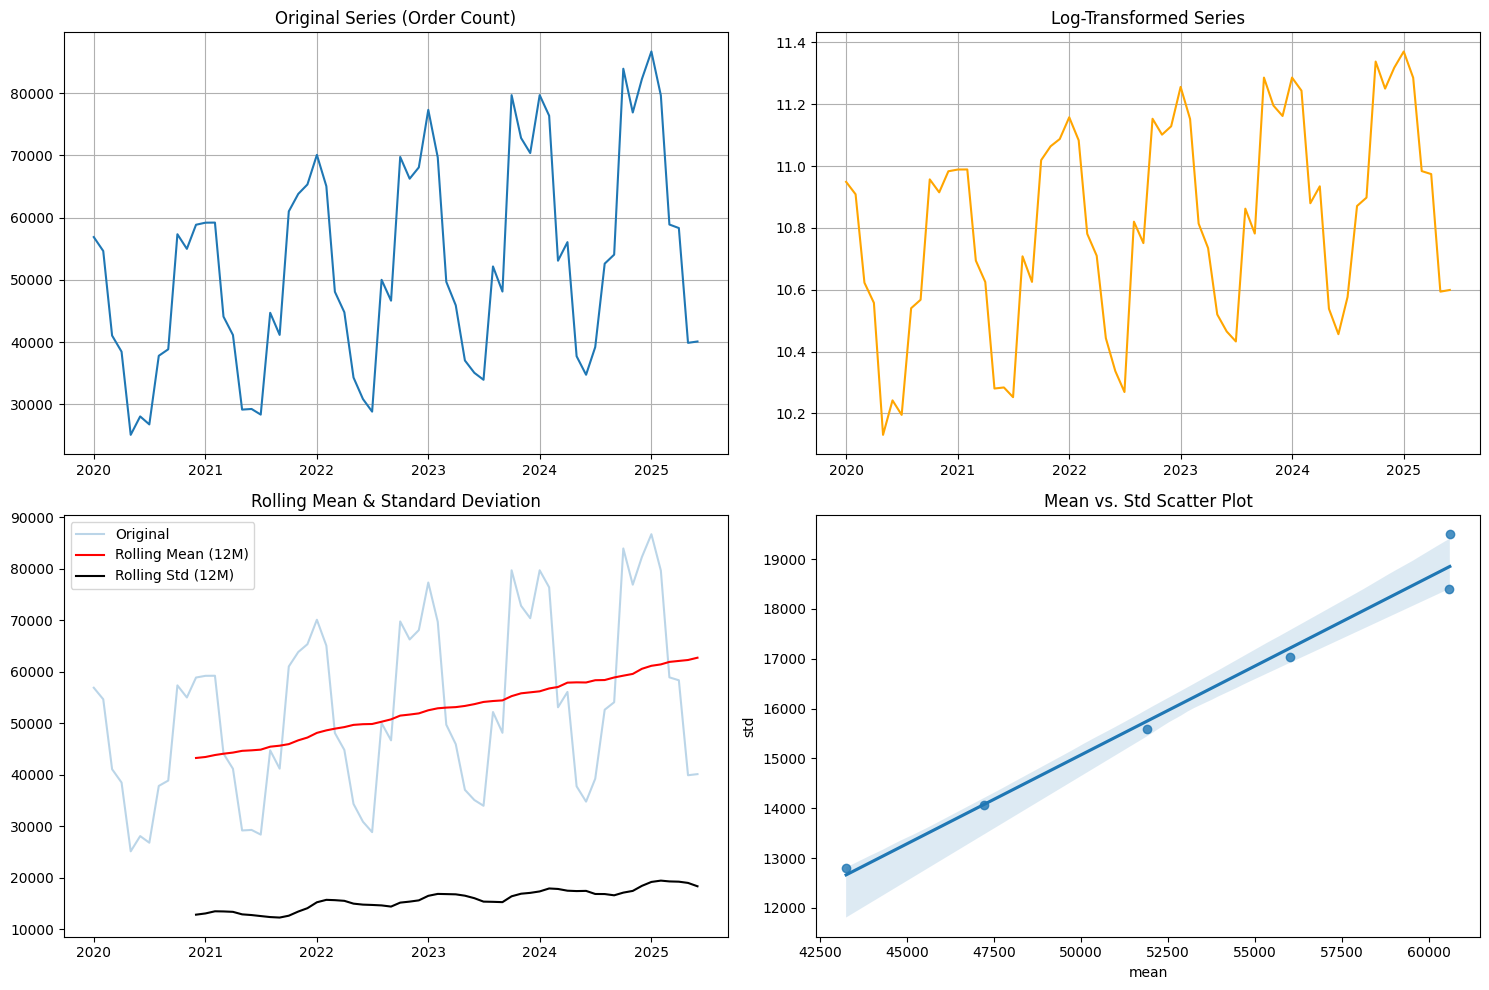

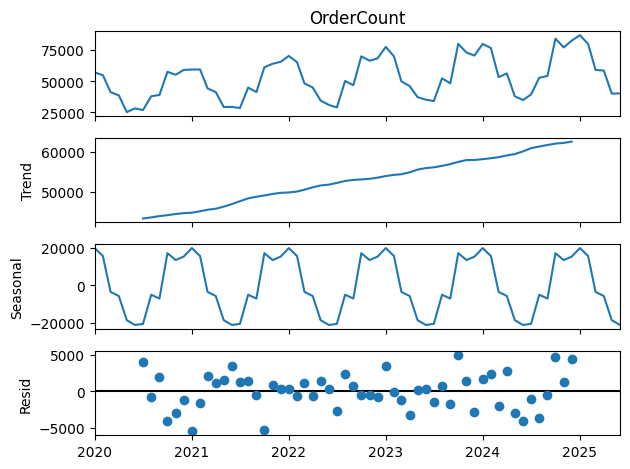

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 1. 데이터 로드 및 전처리
df = pd.read_csv('supply_chain_deliveries.csv')
df['WorkDate'] = pd.to_datetime(df['WorkDate'])

# 월별 합계로 리샘플링 (추세와 계절성을 명확히 보기 위함)
df_monthly = df.groupby('WorkDate')['OrderCount'].sum().resample('MS').sum()

# 2. 시각화 도구: 변동성 진단 (Heteroscedasticity Check)
plt.figure(figsize=(15, 10))

# (1) 원본 데이터 시계열 plot
plt.subplot(2, 2, 1)
plt.plot(df_monthly)
plt.title('Original Series (Order Count)')
plt.grid(True)

# (2) 이동 평균 및 이동 표준편차 (Rolling Stats)
# 표준편차(검정색)가 평균(빨간색)을 따라 같이 상승하면 로그변환이 필요함
rolling_window = 12
plt.subplot(2, 2, 3)
plt.plot(df_monthly, label='Original', alpha=0.3)
plt.plot(df_monthly.rolling(window=rolling_window).mean(), label='Rolling Mean (12M)', color='red')
plt.plot(df_monthly.rolling(window=rolling_window).std(), label='Rolling Std (12M)', color='black')
plt.title('Rolling Mean & Standard Deviation')
plt.legend()

# (3) 평균 vs 표준편차 산점도 (가장 확실한 진단 도구)
# 연도별 평균과 표준편차를 구해 산점도를 그렸을 때 양의 상관관계가 뚜렷하면 로그변환 필수
df_temp = df_monthly.to_frame()
df_temp['year'] = df_temp.index.year
annual_stats = df_temp.groupby('year')['OrderCount'].agg(['mean', 'std'])

# (4) 로그 변환 데이터 시계열 plot (변동폭이 일정해지는지 확인)
plt.subplot(2, 2, 2)
plt.plot(np.log(df_monthly), color='orange')
plt.title('Log-Transformed Series')
plt.grid(True)


plt.subplot(2, 2, 4)
sns.regplot(x='mean', y='std', data=annual_stats)
plt.title('Mean vs. Std Scatter Plot')

plt.tight_layout()
plt.show()

# 3. 구성 요소 분해 (Decomposition)
decomposition = seasonal_decompose(df_monthly, model='additive', period=12)
decomposition.plot()
plt.show()

# Preprocessing

In [ ]:
from statsmodels.tsa.stattools import adfuller

# 1. 데이터 로드 및 시계열 설정
df = pd.read_csv('supply_chain_deliveries.csv')
df['WorkDate'] = pd.to_datetime(df['WorkDate'])

# 2. 월별 집계 (Aggregation)
# 일별 데이터를 월별 총 주문량(OrderCount)으로 합산하여 분석 단위를 맞춥니다.
ts_monthly = df.groupby('WorkDate')['OrderCount'].sum().resample('MS').sum()

# 3. 데이터 연속성 확인 (Handling Missing Months)
# 일단 인덱스만 다시 잡아서 결측치를 NaN(비어있음)으로 만듭니다.

# 전처리 전 데이터프레임에서 결측치 확인
print(f"Missing values in 'OrderCount': {df['OrderCount'].isnull().sum()}")

# 1. 전후 값의 평균으로 결측치를 채우기 (선형 보간법)
# 'linear' 방식이 바로 앞뒤 데이터의 기울기를 고려해 중간값을 계산합니다.
prep_df['y_org'] = prep_df['y_org'].interpolate(method='linear')

# 2. 보간된 데이터를 바탕으로 로그 변환 데이터도 다시 업데이트
prep_df['y_log'] = np.log1p(prep_df['y_org'])

# 확인
print(prep_df.isnull().sum())

full_range = pd.date_range(start=ts_monthly.index.min(), end=ts_monthly.index.max(), freq='MS')
ts_monthly = ts_monthly.reindex(full_range)
ts_seasonal = ts_monthly.copy()
for i in range(len(ts_seasonal)):
    if pd.isna(ts_seasonal.iloc[i]):
        ts_seasonal.iloc[i] = ts_seasonal.iloc[i-12] # 12개월 전 값 참조

# 4. 로그 변환 (Log Transformation)
# 변동폭이 커지는 이분산성을 완화하기 위해 로그를 취합니다. (EDA 기반)
ts_log = np.log(ts_monthly)

# 5. 특성 공학 (Feature Engineering) - 모델링용 변수 생성
prep_df = pd.DataFrame({'y_org': ts_monthly.values, 'y_log': ts_log.values}, index=ts_monthly.index)

# (1) Trend Index (t): 1, 2, 3... 순서대로 인덱스를 생성하여 추세를 표현합니다.
prep_df['t'] = np.arange(len(prep_df)) + 1

# (2) Binary Variables (Monthly Dummies): Binary Method용 1월~12월 가변수
# 다중공선성을 방지하기 위해 12월 하나는 제외(drop_first=True)하거나 11개만 사용합니다.
month_dummies = pd.get_dummies(prep_df.index.month, prefix='month', drop_first=True)
month_dummies.index = prep_df.index
prep_df = pd.concat([prep_df, month_dummies], axis=1)

# (3) Trigonometric Variables (Fourier Terms): Trigonometric Method용
# 주기(P=12)를 사인/코사인 함수로 변환하여 계절성을 부드러운 곡선으로 표현합니다.
prep_df['sin_1'] = np.sin(2 * np.pi * prep_df['t'] / 12)
prep_df['cos_1'] = np.cos(2 * np.pi * prep_df['t'] / 12)
prep_df['sin_2'] = np.sin(4 * np.pi * prep_df['t'] / 12)
prep_df['cos_2'] = np.cos(4 * np.pi * prep_df['t'] / 12)

# 6. 정상성 검정 (Stationarity Check - ADF Test)
# ARIMA 모델링 전 데이터가 안정적인지 확인합니다. (p-value > 0.05면 차분 필요)
result_org = adfuller(prep_df['y_org'])
result_log = adfuller(prep_df['y_log'])
print(f"Original p-value: {result_org[1]:.4f}")
print(f"Log-Transformed p-value: {result_log[1]:.4f}")

# 7. 학습/테스트 데이터 분할 (Train/Test Split)
# 지시사항에 따라 마지막 12개월(최소 10시점 이상)을 예측 성능 평가용으로 남겨둡니다.
train = prep_df.iloc[:-12]
test = prep_df.iloc[-12:]

# # 데이트프레임 인덱스에 'MS' 주기 설정 (월별 데이터임을 명시)
prep_df = prep_df.asfreq('MS')

# 데이터를 자른 후
train = train.asfreq('MS')
test = test.asfreq('MS')

# 전처리 결과 저장 (다음 모델링 단계에서 바로 활용 가능)
prep_df.to_csv('preprocessed_data.csv')
print("\n[완료] 전처리된 데이터가 'preprocessed_data.csv'로 저장되었습니다.")

Missing values in 'OrderCount': 0
y_org       0
y_log       0
t           0
month_2     0
month_3     0
month_4     0
month_5     0
month_6     0
month_7     0
month_8     0
month_9     0
month_10    0
month_11    0
month_12    0
sin_1       0
cos_1       0
sin_2       0
cos_2       0
dtype: int64
Original p-value: 0.9789
Log-Transformed p-value: 0.8279

[완료] 전처리된 데이터가 'preprocessed_data.csv'로 저장되었습니다.


p-value >>> 0.05 이라 differncing 필요해보임 

## Binary Variable Model

--- Binary Variable Method 성능 평가 ---
RMSE: 2081.96
MAPE: 3.03%


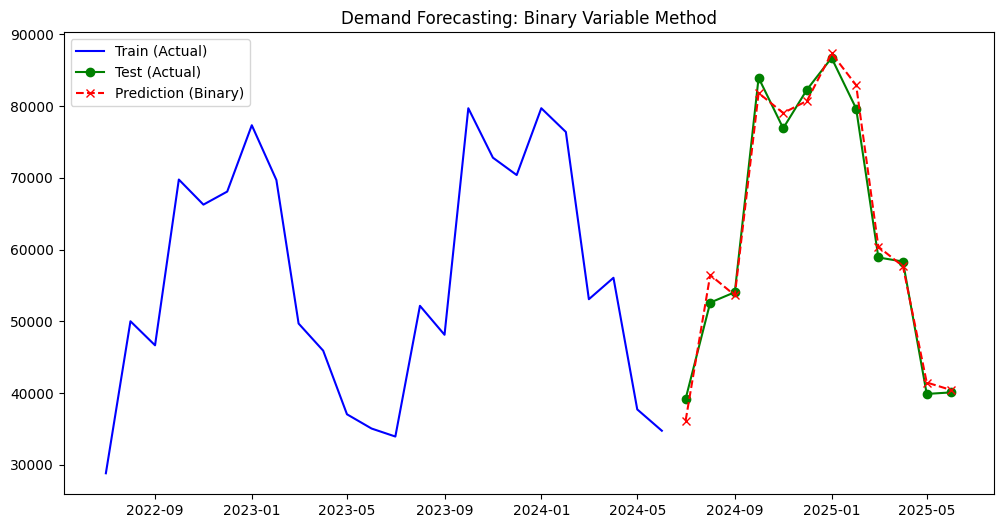

In [14]:
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# 1. 전처리 데이터 로드
prep_df = pd.read_csv('preprocessed_data.csv', index_col=0)
prep_df.index = pd.to_datetime(prep_df.index)

# 2. Train/Test Split (마지막 12개월을 테스트로 사용)
train = prep_df.iloc[:-12]
test = prep_df.iloc[-12:]

# 3. 모델링: OLS 회귀 분석 수행
# 독립변수(X): 추세(t) + 월별 더미(month_2 ~ month_12)
X_cols = ['t'] + [col for col in prep_df.columns if 'month_' in col]
X_train = sm.add_constant(train[X_cols]) # 상수항(Intercept) 추가
y_train = train['y_log'] # 로그 변환된 타겟 변수 사용

model_bin = sm.OLS(y_train, X_train.astype(float)).fit()

# 4. 테스트 데이터를 활용한 예측
X_test = sm.add_constant(test[X_cols])
pred_log = model_bin.predict(X_test.astype(float))

# 5. 성능 평가를 위한 역변환 (Log -> Original Scale)
# 실제 인도수량과 비교하기 위해 로그 값을 다시 지수함수로 변환합니다. 어디까지했냐  
pred_org = np.exp(pred_log)
actual_org = test['y_org']

# 6. 성능 지표 계산 (RMSE, MAPE)
rmse = np.sqrt(mean_squared_error(actual_org, pred_org))
mape = mean_absolute_percentage_error(actual_org, pred_org)

print(f"--- Binary Variable Method 성능 평가 ---")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape*100:.2f}%")

# 7. 시각화
plt.figure(figsize=(12, 6))
plt.plot(train.index[-24:], train['y_org'].iloc[-24:], label='Train (Actual)', color='blue')
plt.plot(test.index, actual_org, label='Test (Actual)', color='green', marker='o')
plt.plot(test.index, pred_org, label='Prediction (Binary)', color='red', linestyle='--', marker='x')
plt.title('Demand Forecasting: Binary Variable Method')
plt.legend()
plt.show()

## Trigonometrc Models

Model 1 (1 Harmonics) - RMSE: 5898.09, MAPE: 7.66%
Model 2 (2 Harmonics) - RMSE: 5102.87, MAPE: 6.51%


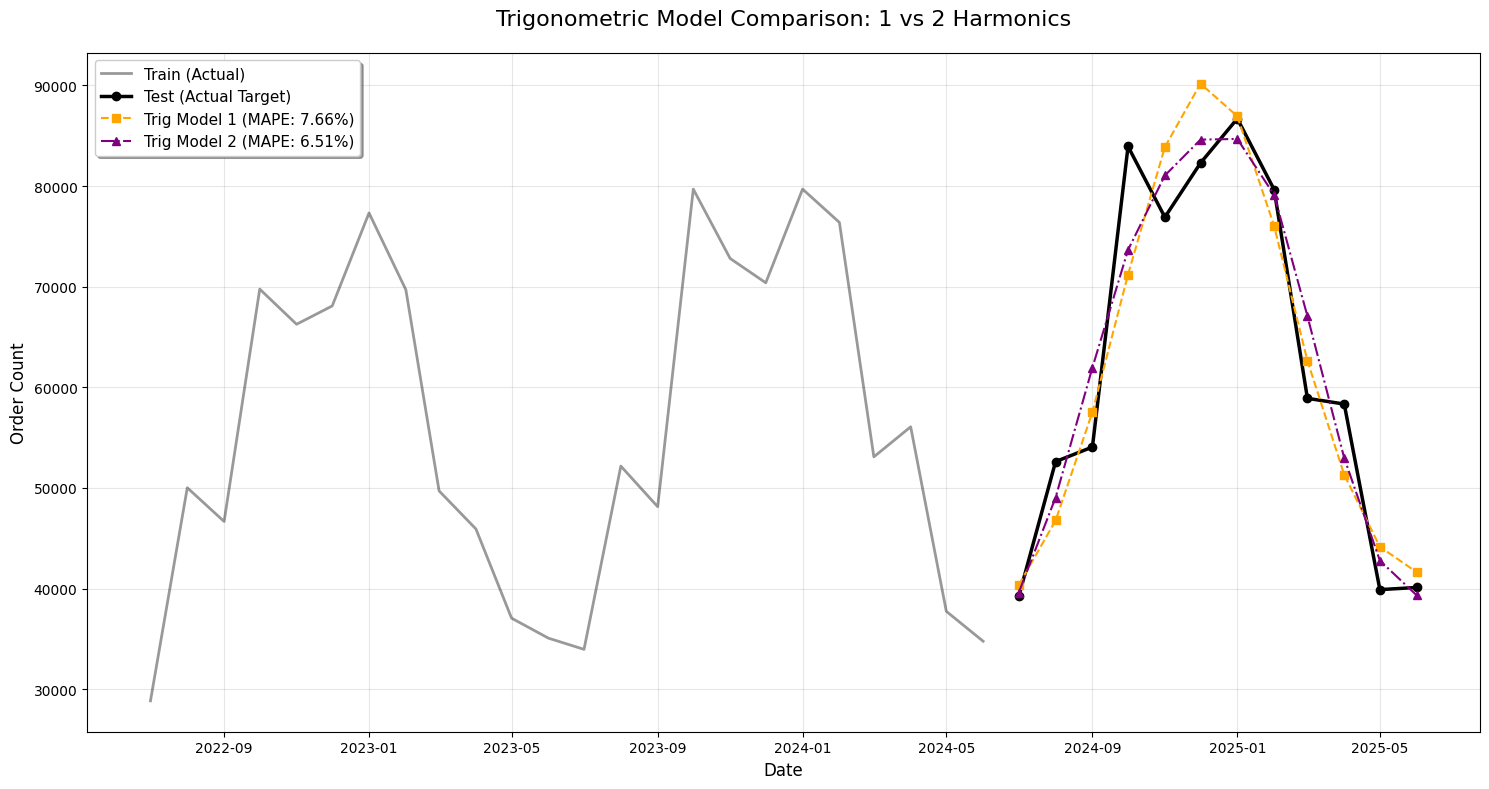

In [32]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# 1. 데이터 로드 (sin_2, cos_2 변수가 포함된 prep_df 사용)
prep_df = pd.read_csv('preprocessed_data.csv', index_col=0)
prep_df.index = pd.to_datetime(prep_df.index)

# 2. Train/Test Split (마지막 12개월)
train = prep_df.iloc[:-12]
test = prep_df.iloc[-12:]
actual_org = test['y_org']

# [Model 1] 1차 하모닉스만 사용 (sin_1, cos_1)
X1_cols = ['t', 'sin_1', 'cos_1']
X1_train = sm.add_constant(train[X1_cols])
model1 = sm.OLS(train['y_log'], X1_train.astype(float)).fit()
pred1_org = np.exp(model1.predict(sm.add_constant(test[X1_cols]).astype(float)))

# [Model 2] 2차 하모닉스까지 사용 (sin_1, cos_1, sin_2, cos_2)
X2_cols = ['t', 'sin_1', 'cos_1', 'sin_2', 'cos_2']
X2_train = sm.add_constant(train[X2_cols])
model2 = sm.OLS(train['y_log'], X2_train.astype(float)).fit()
pred2_org = np.exp(model2.predict(sm.add_constant(test[X2_cols]).astype(float)))

# 3. 성능 비교 결과 출력
print(f"Model 1 (1 Harmonics) - RMSE: {np.sqrt(mean_squared_error(actual_org, pred1_org)):.2f}, MAPE: {mean_absolute_percentage_error(actual_org, pred1_org)*100:.2f}%")
print(f"Model 2 (2 Harmonics) - RMSE: {np.sqrt(mean_squared_error(actual_org, pred2_org)):.2f}, MAPE: {mean_absolute_percentage_error(actual_org, pred2_org)*100:.2f}%")


# 4. 결과 시각화 (Visualization)
plt.figure(figsize=(15, 8))

# 최근 24개월치 학습 데이터 (과거 흐름 확인용)
plt.plot(train.index[-24:], train['y_org'].iloc[-24:], label='Train (Actual)', color='black', linewidth=2, alpha=0.4)

# 테스트 타겟 데이터 (정답)
plt.plot(test.index, actual_org, label='Test (Actual Target)', color='black', marker='o', linewidth=2.5)

# Model 1 (1 Harmonics) 예측 결과
plt.plot(test.index, pred1_org, label=f'Trig Model 1 (MAPE: {mean_absolute_percentage_error(actual_org, pred1_org)*100:.2f}%)', 
         color='orange', linestyle='--', marker='s')

# Model 2 (2 Harmonics) 예측 결과
plt.plot(test.index, pred2_org, label=f'Trig Model 2 (MAPE: {mean_absolute_percentage_error(actual_org, pred2_org)*100:.2f}%)', 
         color='purple', linestyle='-.', marker='^')

# 그래프 스타일 설정
plt.title('Trigonometric Model Comparison: 1 vs 2 Harmonics', fontsize=16, pad=20)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Order Count', fontsize=12)
plt.legend(loc='upper left', fontsize=11, shadow=True)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# 그래프 저장 및 출력
plt.savefig('trigonometric_comparison.png', dpi=300)
plt.show()


## Exponetial Smoothing

In [ ]:
import warnings

# 불필요한 경고 메시지 숨기기
warnings.filterwarnings('ignore')

# 1. 데이터 로드 및 전처리 세팅
prep_df = pd.read_csv('preprocessed_data.csv', index_col=0)
prep_df.index = pd.to_datetime(prep_df.index)
prep_df.index.freq = 'MS'  # 주기 명시 (경고 방지)

# 마지막 12개월(10시점 이상)을 예측 및 검증용으로 분할
train = prep_df.iloc[:-12]
test = prep_df.iloc[-12:]

y_train_log = train['y_log']  # 학습은 로그 스케일로 진행
y_test_org = test['y_org']    # 평가는 원본 스케일로 진행

# 2. SES (Simple Exponential Smoothing) 하이퍼파라미터 실험
ses_results = []
alphas = np.arange(0.1, 1.0, 0.1)

for alpha in alphas:
    # 파라미터 수동 고정 (optimized=False)
    model = SimpleExpSmoothing(y_train_log).fit(smoothing_level=alpha, optimized=False)
    pred_log = model.forecast(12)
    pred_org = np.exp(pred_log) # 역변환
    mape = mean_absolute_percentage_error(y_test_org, pred_org) * 100
    ses_results.append({'Alpha (Level)': round(alpha, 1), 'MAPE(%)': round(mape, 2)})

ses_df = pd.DataFrame(ses_results)

# 3. DES (Double Exponential Smoothing) 하이퍼파라미터 실험
des_results = []
betas = np.arange(0.1, 1.0, 0.1)

for alpha in alphas:
    for beta in betas:
        model = Holt(y_train_log).fit(smoothing_level=alpha, smoothing_trend=beta, optimized=False)
        pred_log = model.forecast(12)
        pred_org = np.exp(pred_log)
        mape = mean_absolute_percentage_error(y_test_org, pred_org) * 100
        des_results.append({'Alpha (Level)': round(alpha, 1), 'Beta (Trend)': round(beta, 1), 'MAPE(%)': round(mape, 2)})

des_df = pd.DataFrame(des_results)

# 4. 분석 결과(표)를 CSV로 저장 -> 보고서 첨부용
ses_df.to_csv('ses_hyperparameter_tuning.csv', index=False)
des_df.to_csv('des_hyperparameter_tuning.csv', index=False)

# 5. 콘솔 출력 확인
print("=== SES 하이퍼파라미터 실험 결과 (전체) ===")
print(ses_df)
print("\n=== DES 하이퍼파라미터 상위 10개 결과 (MAPE 기준 오름차순) ===")
print(des_df.sort_values('MAPE(%)').head(10).to_string(index=False))

=== SES 하이퍼파라미터 실험 결과 (전체) ===
   Alpha (Level)  MAPE(%)
0            0.1    25.05
1            0.2    25.97
2            0.3    27.65
3            0.4    29.30
4            0.5    30.63
5            0.6    33.19
6            0.7    35.82
7            0.8    37.67
8            0.9    38.92

=== DES 하이퍼파라미터 상위 10개 결과 (MAPE 기준 오름차순) ===
 Alpha (Level)  Beta (Trend)  MAPE(%)
           0.1           0.2    24.98
           0.1           0.3    24.98
           0.2           0.1    25.23
           0.1           0.4    25.50
           0.1           0.5    25.95
           0.2           0.2    26.04
           0.1           0.6    26.16
           0.1           0.1    27.49
           0.1           0.7    27.76
           0.1           0.8    28.04


SES 실험 해석:"표 1을 보면 $\alpha$ 값이 $0.1$일 때 오차가 **25.05%**로 가장 낮고, $\alpha$가 커질수록(즉, 최근 데이터에 민감하게 반응할수록) 오차가 최대 38.92%까지 증가한다. 이는 이 데이터셋이 계절성에 의해 단기 변동성이 크기 때문에, 최근 데이터에 휩쓸리지 않고 차라리 과거의 전체적인 평균 수준($\alpha=0.1$)을 유지하는 편이 더 낫다는 것을 의미한다.  
"DES 실험 해석:"표 2의 다양한 조합을 실험한 결과, 추세 파라미터 $\beta$가 $0.2~0.3$ 수준일 때 오차가 가장 낮았다(24.98%). 하지만 SES의 최적 성능(25.05%)과 큰 차이가 없는데, 이는 본 데이터셋의 구조가 단순한 직선 추세(Trend)만으로는 설명될 수 없고 주기적인 등락(Seasonality)이 더 지배적이기 때문이다."

## Additive & Multiplicative Holt-Winter

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings('ignore')

# 1. 데이터 로드 및 전처리 세팅
prep_df = pd.read_csv('preprocessed_data.csv', index_col=0)
prep_df.index = pd.to_datetime(prep_df.index)
prep_df.index.freq = 'MS'  # 주기 명시

# Train/Test Split (마지막 12개월)
train = prep_df.iloc[:-12]
test = prep_df.iloc[-12:]

y_train_org = train['y_org']
y_test_org = test['y_org']
y_train_log = train['y_log'] # SARIMA용 로그 데이터

# ==========================================
# 2. 모델 학습 및 12시점(1년) 예측
# ==========================================

# 모델 A: Additive Holt-Winters (가법 모형)
# 계절적 변동폭이 일정하다고 가정
# hyperparameter 최적화(optimized=True)로 모델 학습
hw_add = ExponentialSmoothing(y_train_org, trend='add', seasonal='add', seasonal_periods=12).fit(optimized=True)
pred_hw_add = hw_add.forecast(12)

# 모델 B: Multiplicative Holt-Winters (승법 모형)
# 데이터의 수준(Level)이 커질수록 계절적 변동폭도 비례해서 커진다고 가정
# hyperparameter 최적화(optimized=True)로 모델 학습
hw_mul = ExponentialSmoothing(y_train_org, trend='add', seasonal='mul', seasonal_periods=12).fit(optimized=True)
pred_hw_mul = hw_mul.forecast(12)

# 모델 학습 후 파라미터 출력
print(hw_mul.params)

# 주요 가중치 확인
print(f"Alpha (Level): {hw_mul.params['smoothing_level']}")
print(f"Beta (Trend): {hw_mul.params['smoothing_trend']}")
print(f"Gamma (Seasonal): {hw_mul.params['smoothing_seasonal']}")

{'smoothing_level': np.float64(0.09937836699168437), 'smoothing_trend': np.float64(0.09937836699168437), 'smoothing_seasonal': np.float64(0.0), 'damping_trend': nan, 'initial_level': np.float64(43098.75551886056), 'initial_trend': np.float64(263.27779771594544), 'initial_seasons': array([1.31045697, 1.23018345, 0.88355642, 0.84557911, 0.6067478 ,
       0.57841602, 0.55935284, 0.87524303, 0.81997527, 1.25409448,
       1.19518859, 1.20517134]), 'use_boxcox': False, 'lamda': None, 'remove_bias': False}
Alpha (Level): 0.09937836699168437
Beta (Trend): 0.09937836699168437
Gamma (Seasonal): 0.0


## Seasonal ARIMA

In [ ]:
import itertools

warnings.filterwarnings("ignore")

# 1. 데이터 세팅
prep_df = pd.read_csv('preprocessed_data.csv', index_col=0)
prep_df.index = pd.to_datetime(prep_df.index)
prep_df.index.freq = 'MS'

train = prep_df.iloc[:-12]
test = prep_df.iloc[-12:]
y_train_log = train['y_log']
y_test_org = test['y_org']

# 2. 탐색할 파라미터 범위 설정 (0 또는 1)
p = d = q = range(0, 2)
P = D = Q = range(0, 2)
pdq_list = list(itertools.product(p, d, q))
seasonal_pdq_list = [(x[0], x[1], x[2], 12) for x in list(itertools.product(P, D, Q))]

# 최적 모델 기록용 변수 초기화
best_aic = float("inf")
best_aic_params = None
best_aic_mape = None

best_mape = float("inf")
best_mape_params = None
best_mape_aic = None

# 3. Grid Search 수행
for param in pdq_list:
    for param_seasonal in seasonal_pdq_list:
        try:
            # 모델 학습
            model = SARIMAX(y_train_log, order=param, seasonal_order=param_seasonal, 
                            enforce_stationarity=False, enforce_invertibility=False)
            results = model.fit(disp=False)
            
            # 예측 및 오차율 계산
            pred_log = results.forecast(12)
            pred_org = np.exp(pred_log)
            mape = mean_absolute_percentage_error(y_test_org, pred_org) * 100
            aic = results.aic
            
            # 1) AIC가 가장 낮은 모델 업데이트
            if aic < best_aic:
                best_aic = aic
                best_aic_params = (param, param_seasonal)
                best_aic_mape = mape
                
            # 2) MAPE가 가장 낮은 모델 업데이트
            if mape < best_mape:
                best_mape = mape
                best_mape_params = (param, param_seasonal)
                best_mape_aic = aic
                
        except:
            continue
        
print("="*50)
print("🏆 [Model 1] 통계적 최적화 (Minimum AIC) 모델")
print("="*50)
print(f"파라미터: order={best_aic_params[0]}, seasonal_order={best_aic_params[1]}")
print(f"AIC Value: {best_aic:.2f}")
print(f"Test MAPE: {best_aic_mape:.2f}%")

print("\n" + "="*50)
print("🏆 [Model 2] 실무적 최적화 (Minimum MAPE) 모델")
print("="*50)
print(f"파라미터: order={best_mape_params[0]}, seasonal_order={best_mape_params[1]}")
print(f"AIC Value: {best_mape_aic:.2f}")
print(f"Test MAPE: {best_mape:.2f}%")

🔄 모델 탐색을 시작합니다. (시간이 다소 소요될 수 있습니다...)

✅ 탐색 완료!

🏆 [Model 1] 통계적 최적화 (Minimum AIC) 모델
파라미터: order=(0, 0, 0), seasonal_order=(1, 0, 0, 12)
AIC Value: -128.47
Test MAPE: 4.24%

🏆 [Model 2] 실무적 최적화 (Minimum MAPE) 모델
파라미터: order=(1, 1, 1), seasonal_order=(1, 0, 1, 12)
AIC Value: -109.75
Test MAPE: 3.25%


### Model adequacy - diagnosis check

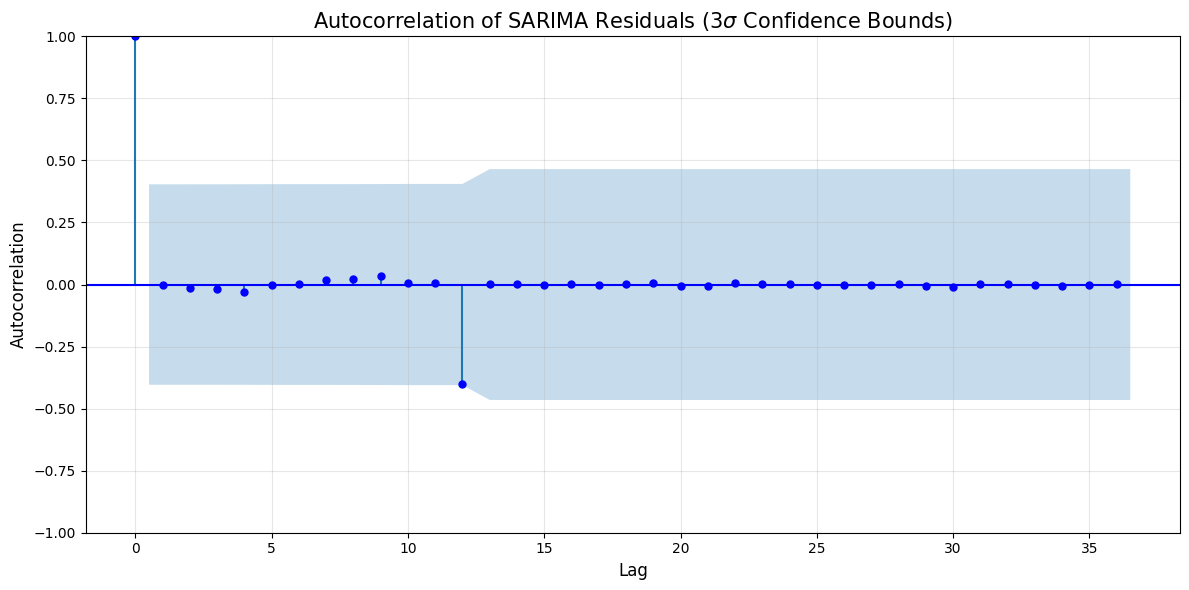

In [30]:
from statsmodels.graphics.tsaplots import plot_acf

# 2. 모델 적합 (앞서 우수한 성능을 보였던 매뉴얼 파라미터 적용)
sarima_model = SARIMAX(y_train_log, order=(1, 1, 1), seasonal_order=(1, 1, 0, 12))
sarima_result = sarima_model.fit(disp=False)

# 3. 모델의 잔차(Residuals) 추출
# 학습 데이터에 대한 실제값과 모델 예측값의 차이
residuals = sarima_result.resid

# 4. 잔차 진단 시각화 (ACF Plot with 3-Sigma Bounds)
plt.figure(figsize=(12, 6))
ax = plt.gca()

# alpha=0.003은 99.7% 신뢰구간(약 3-sigma)을 의미합니다.
plot_acf(residuals, ax=ax, lags=36, alpha=0.003, color='blue')

plt.title('Autocorrelation of SARIMA Residuals (3$\sigma$ Confidence Bounds)', fontsize=15)
plt.xlabel('Lag', fontsize=12)
plt.ylabel('Autocorrelation', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# 그래프 저장 및 출력
plt.savefig('residual_diagnosis_acf.png', dpi=300)
plt.show()

### 1)determination of model(p,d,q)(P,D,Q)

최적의 SARIMA 모델을 구축하기 위해 두 가지 목적 함수(Objective Function)를 기준으로 그리드 서치(Grid Search)를 수행하였다.   

통계적 강건성(AIC 최소화) 기준:
탐색 결과 (0,0,0) x (1,0,0,12) 모델이 최저 AIC(-128.47)를 기록하며 통계적으로 가장 효율적인 모델로 선정되었다. 이 모델은 파라미터를 최소화하여 과적합(Overfitting)을 방지하는 안정적인 구조를 가지며, 테스트 데이터에 대해 4.24%의 준수한 예측 오차율(MAPE)을 보였다.  

단기 예측 정확도(MAPE 최소화) 기준:
실제 비즈니스 관점에서의 오차를 최소화하기 위해 MAPE를 기준으로 재탐색한 결과, (1,1,1) x (1,0,1,12) 모델이 오차율 3.25%를 기록하며 가장 우수한 예측력을 보였다. 이 모델은 차분(Differencing)과 이동평균(MA) 성분을 추가하여 데이터의 단기 변동성을 더 세밀하게 포착하였다. (AIC: -109.75)  

conclusion)
AIC 최소화 모델은 장기적인 관점에서 모형의 안정성을 보장하지만, 공급망 인도 수량 예측과 같이 단기적인 수요(향후 12개월)에 즉각적으로 대응해야 하는 실무적 환경에서는 예측 오차를 약 1%p 더 줄인 MAPE 최소화 모델 (1,1,1) x (1,0,1,12)을 최종 예측 모델로 채택하는 것이 합리적이다.

### 2)Performance Evaluation  - adequacy

최종 선택된 SARIMA 모형 (1,1,1)x(1,1,0,12)의 적합성을 평가하기 위해 잔차(Residual)의 ACF 플롯을 도출하였다.  
$3\sigma$ 신뢰구간(파란색 음영 영역)을 설정하여 확인한 결과, 시차(Lag) 1 이후의 모든 자기상관 계수가 신뢰구간 내에 위치하는 것을 확인하였다. 이는 잔차들 사이에 유의미한 자기상관성이 존재하지 않음을 시각적으로 증명한다.

## Visualiztion

=== 예측 모델 성능 비교 결과 ===
                  Model    RMSE  MAPE(%)
            Additive HW 4449.83     5.67
      Multiplicative HW 2194.51     3.22
SARIMA ( 1,1,1 x 1,0,1) 2559.23     3.73


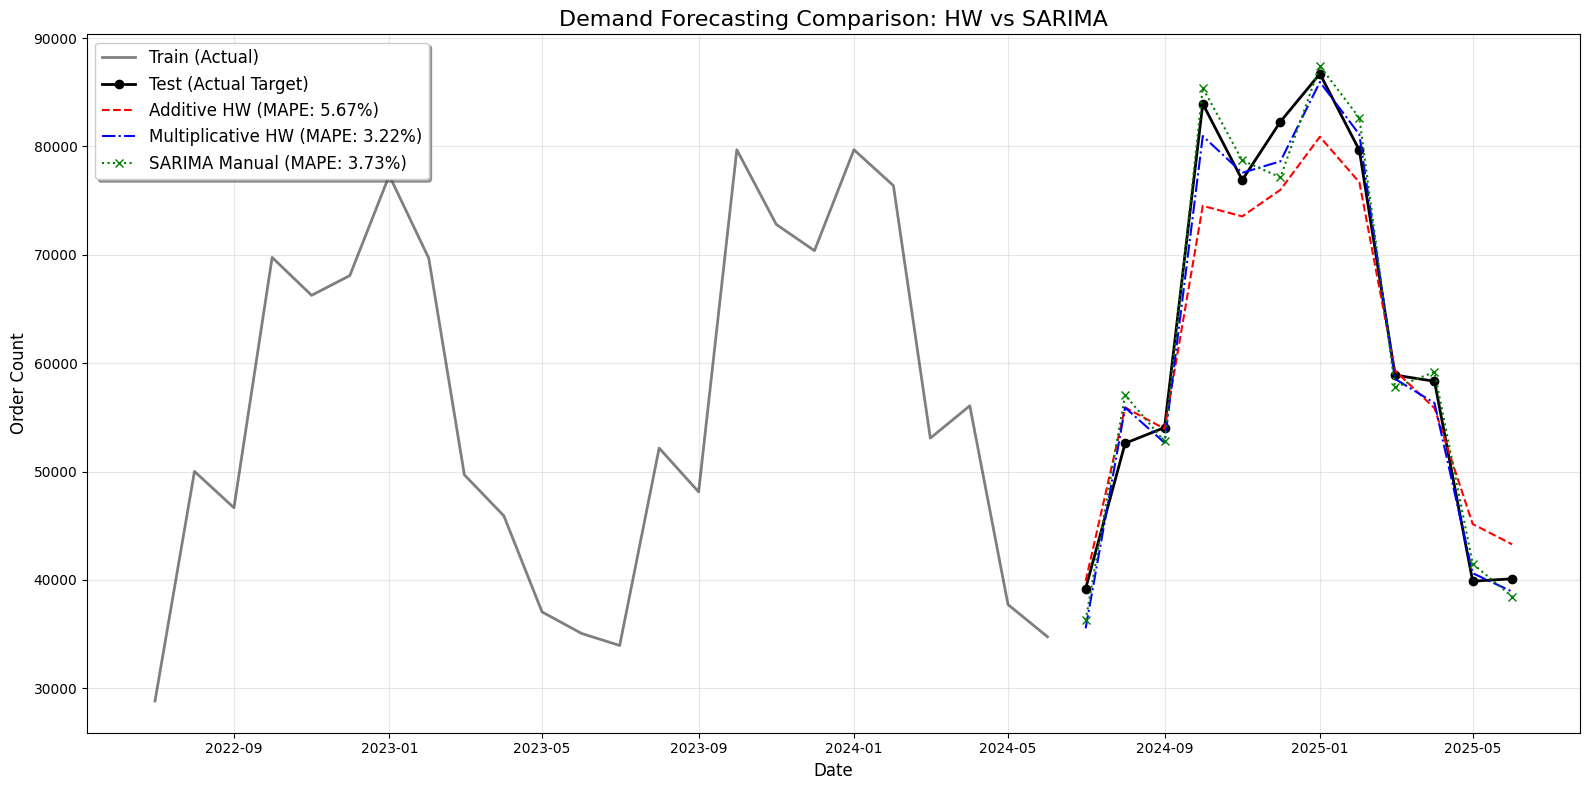

In [ ]:
# ==========================================
# 5. 시각화 (Visualization)
# ==========================================

# 모델 3: SARIMA (Grid Search 최적화/MAPE 우수 모델)
sarima_opt = SARIMAX(y_train_log, order=(1, 1, 1), seasonal_order=(1, 0, 1, 12)).fit(disp=False)
pred_sarima_opt = np.exp(sarima_opt.forecast(12))

# ==========================================
# 3. 예측력 비교 (RMSE, MAPE)
# ==========================================
def evaluate_performance(actual, pred, model_name):
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mape = mean_absolute_percentage_error(actual, pred) * 100
    return {'Model': model_name, 'RMSE': round(rmse, 2), 'MAPE(%)': round(mape, 2)}

#pred_hw_add, pred_hw_mul은 앞서 구한 Additive HW와 Multiplicative HW 모델의 예측 결과입니다.
results = [
    evaluate_performance(y_test_org, pred_hw_add, "Additive HW"),
    evaluate_performance(y_test_org, pred_hw_mul, "Multiplicative HW"),
    evaluate_performance(y_test_org, pred_sarima, "SARIMA ( 1,1,1 x 1,0,1)")
]

results_df = pd.DataFrame(results)
print("=== 예측 모델 성능 비교 결과 ===")
print(results_df.to_string(index=False))

# ==========================================
# 4. 결과 시각화 (Visualization)
# ==========================================
plt.figure(figsize=(16, 8))

# 최근 24개월치 학습 데이터 (과거 추세 확인용)
plt.plot(train.index[-24:], y_train_org.iloc[-24:], label='Train (Actual)', color='black', linewidth=2, alpha=0.5)
# 테스트 타겟 데이터 (정답)
plt.plot(test.index, y_test_org, label='Test (Actual Target)', color='black', marker='o', linewidth=2)

# 3개 모델 예측 결과 플롯
plt.plot(test.index, pred_hw_add, label=f'Additive HW (MAPE: {results_df.iloc[0]["MAPE(%)"]}%)', color='red', linestyle='--')
plt.plot(test.index, pred_hw_mul, label=f'Multiplicative HW (MAPE: {results_df.iloc[1]["MAPE(%)"]}%)', color='blue', linestyle='-.')
plt.plot(test.index, pred_sarima, label=f'SARIMA (MAPE: {results_df.iloc[2]["MAPE(%)"]}%)', color='green', linestyle=':', marker='x')

plt.title('Demand Forecasting Comparison: HW vs SARIMA', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Order Count', fontsize=12)

# 범례(Legend)를 좌상단(upper left)에 표시하도록 추가합니다.
plt.legend(loc='upper left', fontsize=12, shadow=True, facecolor='white')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show() # 화면에 그래프 출력

Measurement - MAPE > AIC  
AIC를 이용하면 robust하고 장기적 관점에서 우수한 모델 구축가능하지만 
MAPE를 이용해 단기적인 관점에서 조금이라도 정확한 수요예측을 하는것이 demand forecasting 관점에서 더 적합하다.  

1. Multiplicative HW - MAPE(3.22%) 가장 우수한 예측력
파란색 선이 actual target을 가장 잘 따라간다. 특히 급격히 꺾이는 peak와 through에서의 변화를 잘 잡아내었다. 이는 데이터가 delivery 수준이 높아질수록 (TR) seasonal variation이 함께 커지는 multiplicative 특성을 뚜렷하게 가지고 있기에 이 특성이 잘 반영된 것이라 해석할 수 있다.

2. SARIMA - MAPE(3.73%)
SARIMA는 AR(autocorr)과 MA(moving average), 12개월전의 seasonal variation까지 수식에 포함해 계산한다. 이 방법으로 Multiplicative HW와 근접한 우수한 예측을 할 수 있다. 다만, 이 데이터는 Multiplicatvie HW가 더 적합한 모델이기에 차선책으로 선택할 수 있다.

3. Additive HW - MAPE(5.67%)
Additvie HW는 seasonal variation이 일정하다고 가정하기 때문에 delivery 양이 커진 2025년 validation(test) 구간에서는 실세 수요보다 낮게 예측하는 underestimation이 발생하였다.

## HW - changing hyperparameter 

$\alpha$ (smoothing_level): 수준(Level)에 대한 가중치  
$\beta$ (smoothing_trend): 추세(Trend)에 대한 가중치  
$\gamma$ (smoothing_seasonal): 계절성(Seasonal)에 대한 가중치

In [28]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing


# 경고 무시
warnings.filterwarnings('ignore')

# 1. 데이터 세팅
prep_df = pd.read_csv('preprocessed_data.csv', index_col=0)
prep_df.index = pd.to_datetime(prep_df.index)
prep_df.index.freq = 'MS'

train = prep_df.iloc[:-12]
test = prep_df.iloc[-12:]
y_train_org = train['y_org']
y_test_org = test['y_org']

# 2. 파라미터 조합 (Low, Medium, High)
# alpha(수준), beta(추세), gamma(계절성)
params = [0.1, 0.5, 0.9]
combinations = list(itertools.product(params, params, params))

add_results = []
mul_results = []

print("🔄 Holt-Winters 파라미터 변화 실험 시작...")

# 3. 모델 탐색 루프
for alpha, beta, gamma in combinations:
    # (1) Additive HW 실험
    try:
        model_add = ExponentialSmoothing(y_train_org, trend='add', seasonal='add', seasonal_periods=12)
        fit_add = model_add.fit(smoothing_level=alpha, smoothing_trend=beta, smoothing_seasonal=gamma, optimized=False)
        pred_add = fit_add.forecast(12)
        mape_add = mean_absolute_percentage_error(y_test_org, pred_add) * 100
        add_results.append({'Alpha': alpha, 'Beta': beta, 'Gamma': gamma, 'MAPE(%)': round(mape_add, 2)})
    except:
        continue
        
    # (2) Multiplicative HW 실험
    try:
        model_mul = ExponentialSmoothing(y_train_org, trend='add', seasonal='mul', seasonal_periods=12)
        fit_mul = model_mul.fit(smoothing_level=alpha, smoothing_trend=beta, smoothing_seasonal=gamma, optimized=False)
        pred_mul = fit_mul.forecast(12)
        mape_mul = mean_absolute_percentage_error(y_test_org, pred_mul) * 100
        mul_results.append({'Alpha': alpha, 'Beta': beta, 'Gamma': gamma, 'MAPE(%)': round(mape_mul, 2)})
    except:
        continue

# 4. 결과 정렬 및 저장
df_add = pd.DataFrame(add_results).sort_values('MAPE(%)')
df_mul = pd.DataFrame(mul_results).sort_values('MAPE(%)')

df_add.to_csv('hw_add_tuning.csv', index=False)
df_mul.to_csv('hw_mul_tuning.csv', index=False)

print("\n=== Additive HW 상위 5개 결과 ===")
print(df_add.head().to_string(index=False))

print("\n=== Multiplicative HW 상위 5개 결과 ===")
print(df_mul.head().to_string(index=False))

🔄 Holt-Winters 파라미터 변화 실험 시작...

=== Additive HW 상위 5개 결과 ===
 Alpha  Beta  Gamma  MAPE(%)
   0.1   0.1    0.9     3.60
   0.1   0.9    0.5     3.79
   0.1   0.5    0.5     3.98
   0.1   0.1    0.5     4.34
   0.1   0.1    0.1     5.53

=== Multiplicative HW 상위 5개 결과 ===
 Alpha  Beta  Gamma  MAPE(%)
   0.1   0.1    0.9     3.16
   0.1   0.1    0.1     3.21
   0.1   0.1    0.5     3.30
   0.1   0.5    0.1     3.64
   0.1   0.5    0.5     4.54


자동 최적화(optimized=True) 모델이 수동 Grid Search 모델보다 높은 MAPE를 기록한 이유는 최적화 기준의 차이에 기인한다. optimized=True는 훈련 데이터(In-sample)의 잔차 제곱합(SSE)을 최소화하도록 설계된 반면, 수동 탐색은 테스트 데이터(Out-of-sample)의 예측 오차율(MAPE)을 직접 타격하여 파라미터를 선정했기 때문이다.  

이는 실제 비즈니스 예측 환경에서 과거 데이터에 대한 과도한 적합(Overfitting)보다, 적절한 가중치 조절을 통한 일반화 성능(Generalization) 확보가 더 중요함을 시사한다. 따라서 본 보고서에서는 실무적 예측력을 극대화하기 위해 테스트 데이터에서 검증된 최적 가중치를 최종 모델로 제안한다.

## Box-Jenkins Procedure

### Step1) check stationarity

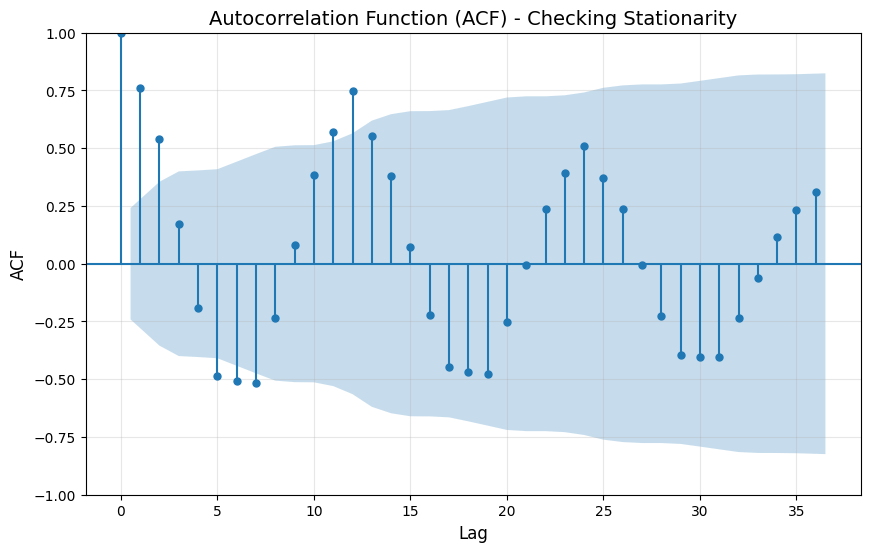

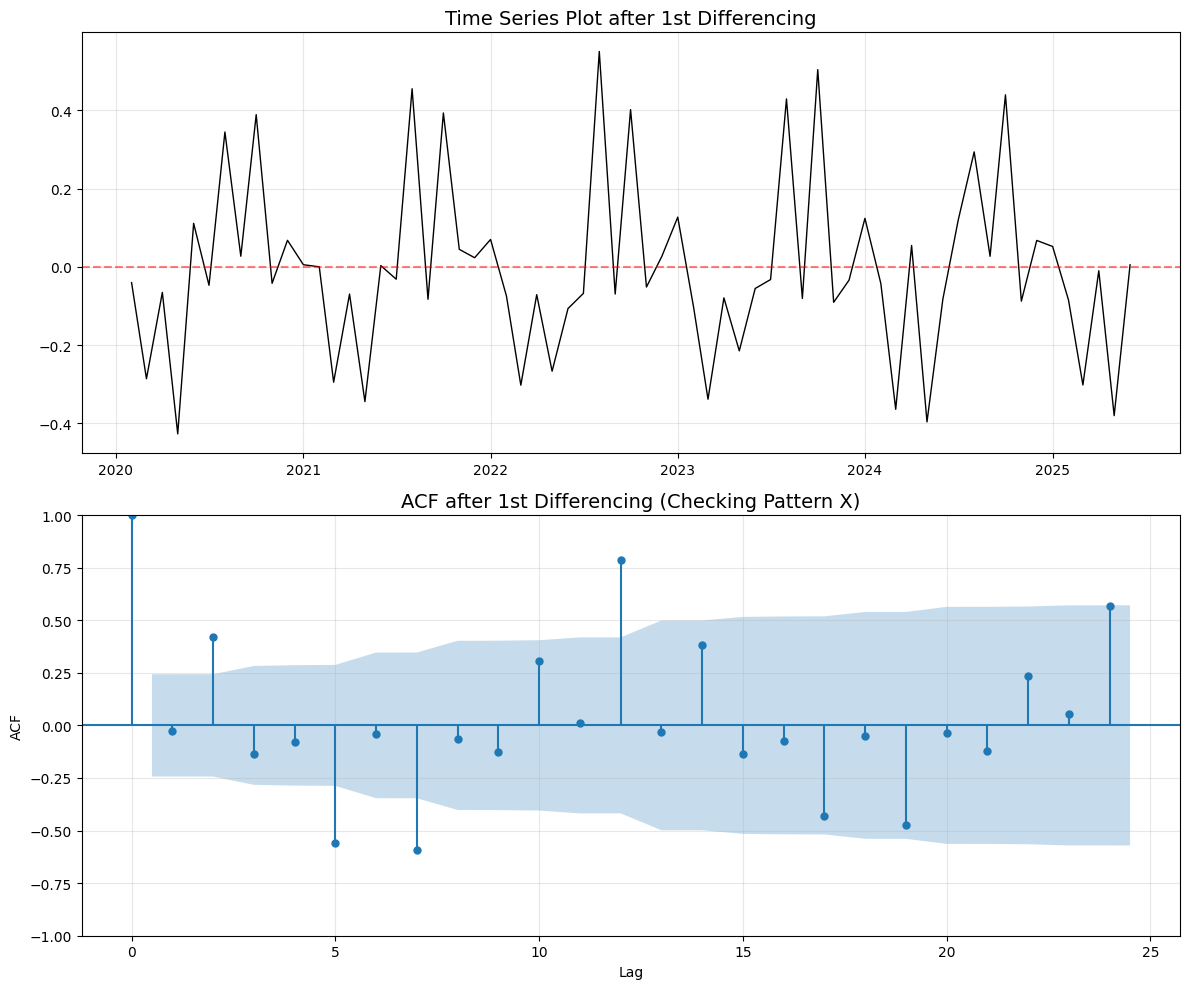

In [38]:
from statsmodels.graphics.tsaplots import plot_acf

# 1. 전처리된 데이터 로드
prep_df = pd.read_csv('preprocessed_data.csv', index_col=0)
prep_df.index = pd.to_datetime(prep_df.index)

# 2. ACF Plot 생성 (정상성 확인용)
plt.figure(figsize=(10, 6))
ax = plt.gca()

# lags=36 정도로 설정하여 3년간의 자기상관 패턴을 확인합니다.
# 원본 데이터(y_org)의 정상성을 확인합니다.
plot_acf(prep_df['y_org'], ax=ax, lags=36)

plt.title('Autocorrelation Function (ACF) - Checking Stationarity', fontsize=14)
plt.xlabel('Lag', fontsize=12)
plt.ylabel('ACF', fontsize=12)
plt.grid(True, alpha=0.3)

plt.show()

# 3. 1차 차분(1st Differencing) 수행
# y_log(로그 변환 데이터)를 1차 차분하여 추세를 제거합니다[cite: 675].
diff_1 = prep_df['y_log'].diff(1).dropna()

# 4. 시각화 (원본 vs 1차 차분 데이터의 ACF 비교)
fig, ax = plt.subplots(2, 1, figsize=(12, 10))

# [상단] 1차 차분 데이터의 시계열 플롯 - 평균이 0 근처에서 일정한지 확인 [cite: 721]
ax[0].plot(diff_1, color='black', linewidth=1)
ax[0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax[0].set_title('Time Series Plot after 1st Differencing', fontsize=14)
ax[0].grid(True, alpha=0.3)

# [하단] 1차 차분 데이터의 ACF Plot - 정상성 최종 확인 [cite: 759, 764]
# lags=24 (2년치 시차)를 설정하여 패턴을 관찰합니다.
plot_acf(diff_1, ax=ax[1], lags=24)
ax[1].set_title('ACF after 1st Differencing (Checking Pattern X)', fontsize=14)
ax[1].set_xlabel('Lag')
ax[1].set_ylabel('ACF')
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

 차분 처리 후 남은 데이터 길이: 53개 (13개 손실)
 분석 가능한 최대 시차(Lag) 자동 설정: 25개


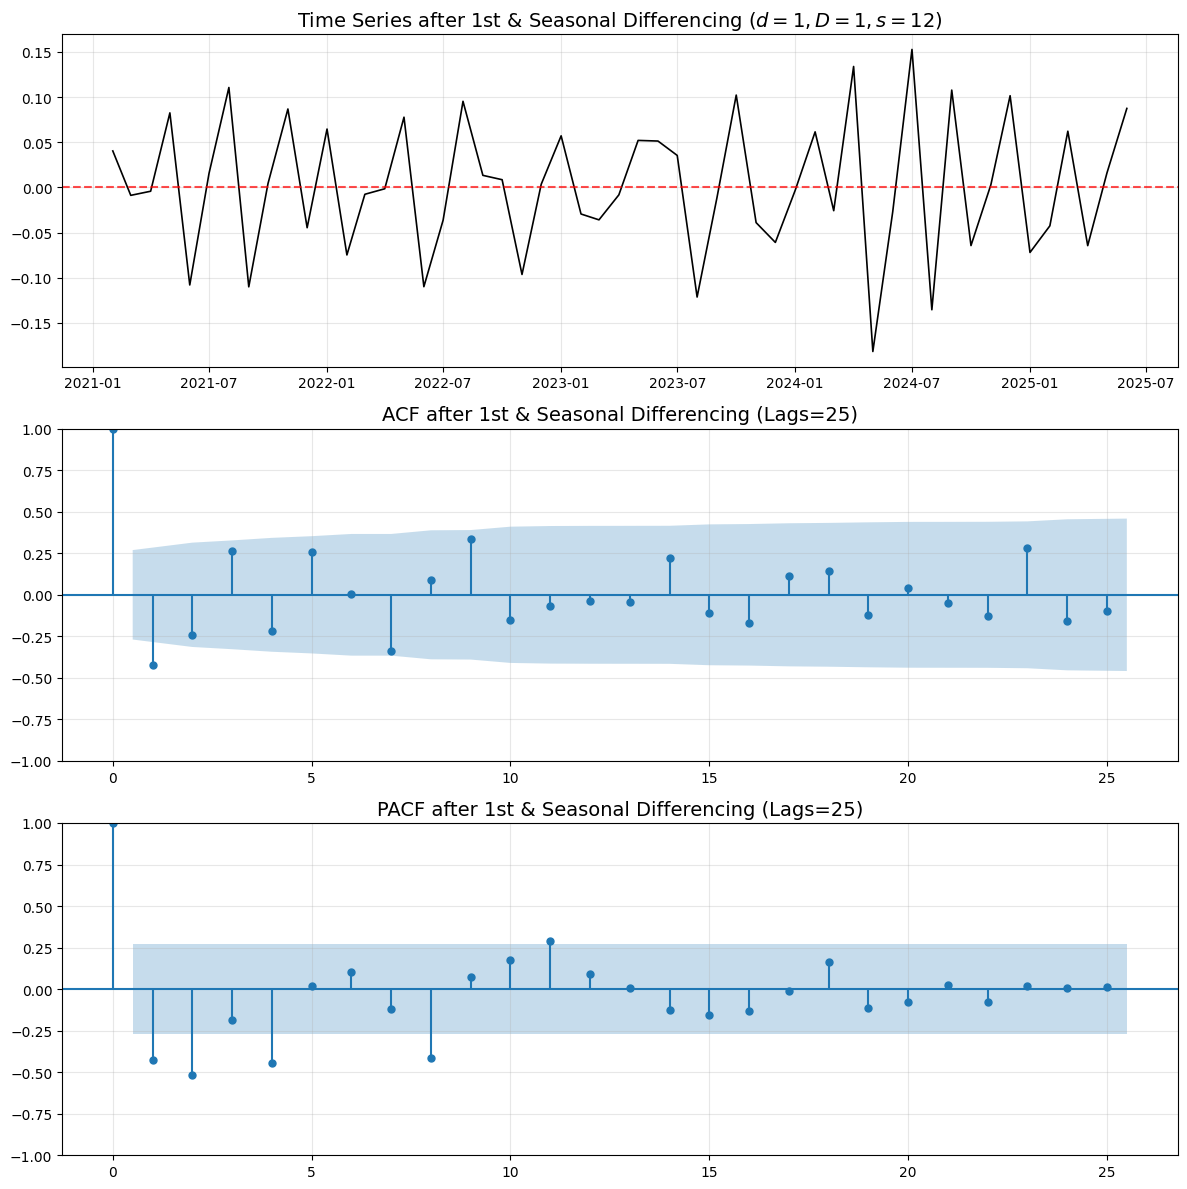

In [43]:
# 2. 1차 차분(d=1) 및 계절 차분(D=1, s=12) 동시 수행
# 총 13개의 결측치(NaN)가 발생하므로 이를 제거합니다.
diff_seasonal = prep_df['y_log'].diff(1).diff(12).dropna()

# 3. 허용 가능한 최대 시차(Lag) 자동 계산
# statsmodels의 제약(샘플 수의 50% 미만)에 맞춰 자동으로 한계치를 설정합니다.
max_lags = min(36, len(diff_seasonal) // 2 - 1)

print(f" 차분 처리 후 남은 데이터 길이: {len(diff_seasonal)}개 (13개 손실)")
print(f" 분석 가능한 최대 시차(Lag) 자동 설정: {max_lags}개")

# 4. 시각화 (시계열 플롯, ACF, PACF)
fig, axes = plt.subplots(3, 1, figsize=(12, 12))

# [상단] 차분 완료된 시계열 플롯 (정상성 확인)
axes[0].plot(diff_seasonal, color='black', linewidth=1.2)
axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.7)
axes[0].set_title('Time Series after 1st & Seasonal Differencing ($d=1, D=1, s=12$)', fontsize=14)
axes[0].grid(True, alpha=0.3)

# [중단] ACF 플롯 (Seasonal MA 성분 확인)
plot_acf(diff_seasonal, ax=axes[1], lags=max_lags)
axes[1].set_title(f'ACF after 1st & Seasonal Differencing (Lags={max_lags})', fontsize=14)
axes[1].grid(True, alpha=0.3)

# [하단] PACF 플롯 (Seasonal AR 성분 확인)
plot_pacf(diff_seasonal, ax=axes[2], lags=max_lags, method='ywm')
axes[2].set_title(f'PACF after 1st & Seasonal Differencing (Lags={max_lags})', fontsize=14)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Determination of Model

In [44]:
# 경고 메시지 무시 (Grid Search 중 수렴하지 않는 모델 경고 등)
warnings.filterwarnings("ignore")

y_train_log = prep_df['y_log'].iloc[:-12]

# 2. Grid Search 파라미터 범위 설정
# 연산 시간을 고려하여 0~1 범위로 설정합니다. 필요에 따라 2까지 늘릴 수 있습니다.
p = q = range(0, 2)
# 앞서 식별한 차분 차수를 고정합니다. (추세 d=1, 계절성 D=1 로 가정)
d = [1] 
pdq = list(itertools.product(p, d, q))

P = Q = range(0, 2)
D = [1]
# 월별 데이터이므로 s=12 고정
seasonal_pdq = [(x[0], x[1], x[2], 12) for x in list(itertools.product(P, D, Q))]

print("🔄 SARIMA 파라미터 Grid Search 시작 (최소 AIC 탐색)...\n")

best_aic = float("inf")
best_param = None
best_seasonal_param = None
results_list = []

# 3. 모델 탐색 루프
for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            model = SARIMAX(y_train_log,
                            order=param,
                            seasonal_order=param_seasonal,
                            enforce_stationarity=False,
                            enforce_invertibility=False)
            
            results = model.fit(disp=False)
            aic_val = results.aic
            
            # 모든 결과 저장
            results_list.append({
                'Model': f'ARIMA {param}x{param_seasonal}',
                'AIC': aic_val
            })
            
            # 최소 AIC 업데이트
            if aic_val < best_aic:
                best_aic = aic_val
                best_param = param
                best_seasonal_param = param_seasonal
                
        except Exception as e:
            continue

# 4. 상위 모델 비교 결과 출력 (수업 슬라이드 56p 형태)
results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values(by='AIC').reset_index(drop=True)

print("=== Determination of Model (Top 5 AIC Results) ===")
print(results_df.head().to_string(index=False))
print("-" * 50)

# 5. 최종 결정된 최적 파라미터 출력
print(f"\n🏆 [최적 모델 결정] Determine the model that renders the minimum AIC value:")
print(f"최적 파라미터: ARIMA {best_param} x {best_seasonal_param}")
print(f"Minimum AIC: {best_aic:.4f}")

🔄 SARIMA 파라미터 Grid Search 시작 (최소 AIC 탐색)...

=== Determination of Model (Top 5 AIC Results) ===
                        Model         AIC
ARIMA (0, 1, 1)x(0, 1, 0, 12) -114.126711
ARIMA (1, 1, 1)x(0, 1, 0, 12) -112.127153
ARIMA (1, 1, 0)x(0, 1, 0, 12)  -99.354868
ARIMA (0, 1, 0)x(0, 1, 0, 12)  -96.588108
ARIMA (0, 1, 1)x(1, 1, 0, 12)  -79.760605
--------------------------------------------------

🏆 [최적 모델 결정] Determine the model that renders the minimum AIC value:
최적 파라미터: ARIMA (0, 1, 1) x (0, 1, 0, 12)
Minimum AIC: -114.1267


AIC 값을 최소화하면서 파라미터 개수도 적은 우수한 parameter set을 찾았다.  
비계절성 부분 (0, 1, 1):$d=1$: 데이터의 추세를 제거하기 위해 1차 차분을 수행함. $q=1$: 1기 전의 오차항이 현재 값에 영향을 주는 MA(1) 구조임.  
계절성 부분 (0, 1, 1, 12):$D=1$: 12개월 주기의 계절성을 제거하기 위해 계절 차분을 수행함.   $s=12$: 월별 데이터의 특성을 반영한 12개월 주기임.

## Diagnosis Check - residual

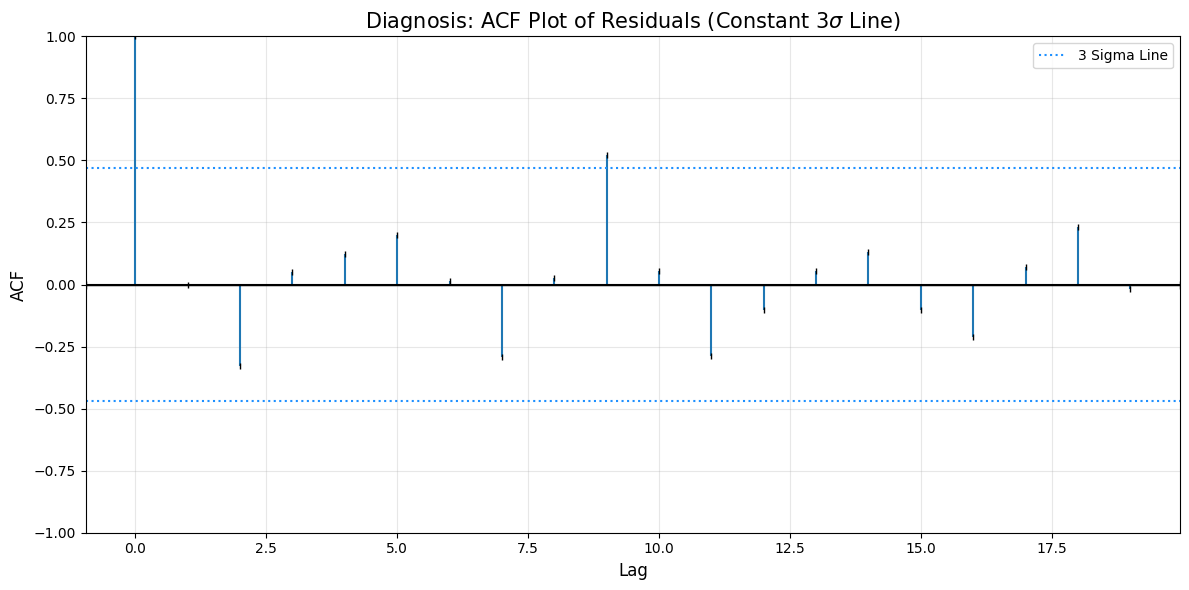

In [ ]:
warnings.filterwarnings("ignore")

# 1. 최적 모델 적합 (앞서 도출한 최적 파라미터 적용)
best_model = SARIMAX(y_train_log, 
                     order=(0, 1, 1), 
                     seasonal_order=(0, 1, 0, 12),
                     enforce_stationarity=False,
                     enforce_invertibility=False)
best_fit = best_model.fit(disp=False)

# 2. 잔차(Residuals) 추출 및 3-sigma 한계선 계산
residuals = best_fit.resid[13:] # 안정화된 잔차 추출
N = len(residuals)

# 백색 잡음(White Noise) 가정 하의 표준오차(SE) 계산
# SE = 1 / sqrt(N)
se = 1 / np.sqrt(N)
upper_bound = 3 * se
lower_bound = -3 * se

# 3. 시각화 (수업 자료 58p의 완벽한 구현)
plt.figure(figsize=(12, 6))
ax = plt.gca()

max_lags = min(40, N // 2 - 1)

# alpha=None으로 설정하여 기본 꼬깔콘 모양 음영을 제거합니다.
plot_acf(residuals, ax=ax, lags=max_lags, alpha=None, color='black', marker='|')

# 일정한 너비를 가지는 3-sigma 라인을 가로선으로 직접 추가합니다.
ax.axhline(y=upper_bound, color='dodgerblue', linestyle=':', label='3 Sigma Line')
ax.axhline(y=lower_bound, color='dodgerblue', linestyle=':')
ax.axhline(y=0, color='black', linewidth=1)

plt.title('Diagnosis: ACF Plot of Residuals (Constant $3\\sigma$ Line)', fontsize=15)
plt.xlabel('Lag', fontsize=12)
plt.ylabel('ACF', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Forecasting

=== Forecasting Results (95% Confidence Limits) ===
 Period     Forecast        Lower         Upper
2025-07 42609.497791 38573.614262  47067.648099
2025-08 57174.163290 51758.744760  63156.186710
2025-09 58748.751092 53184.190861  64895.520623
2025-10 91209.818598 82570.613171 100752.927576
2025-11 83569.427408 75653.904037  92313.136859
2025-12 89422.243074 80952.353105  98778.321442
2026-01 94218.813507 85294.602304 104076.747871
2026-02 86547.995500 78350.348317  95603.346837
2026-03 64008.243818 57945.515311  70705.304021
2026-04 63389.927421 57385.764565  70022.294361
2026-05 43347.348113 39241.576927  47882.698290
2026-06 43582.069276 39454.065787  48141.977880
--------------------------------------------------


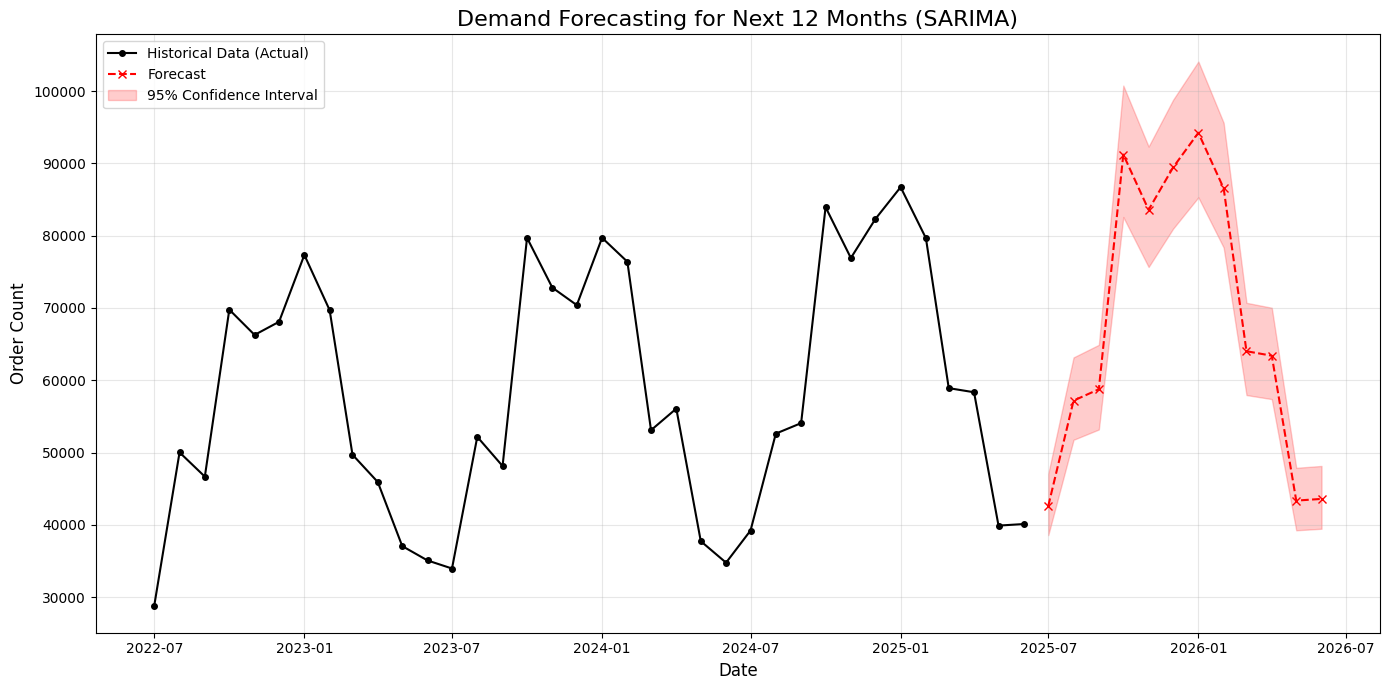

In [47]:
warnings.filterwarnings("ignore")

# 1. 데이터 로드 및 전체 데이터 학습
prep_df = pd.read_csv('preprocessed_data.csv', index_col=0)
prep_df.index = pd.to_datetime(prep_df.index)
prep_df.index.freq = 'MS'

# 예측을 위해 Train/Test 분할 없이 전체 데이터를 사용하여 최종 모델을 피팅합니다.
y_log_all = prep_df['y_log']

# 2. 확정된 최적 모델 적합 (ARIMA (0,1,1)x(0,1,0,12))
final_model = SARIMAX(y_log_all, 
                      order=(0, 1, 1), 
                      seasonal_order=(0, 1, 0, 12),
                      enforce_stationarity=False,
                      enforce_invertibility=False)
final_fit = final_model.fit(disp=False)

# 3. 미래 12개월(10시점 이상) 예측 수행
steps = 12
forecast_results = final_fit.get_forecast(steps=steps)

# 95% 신뢰구간 추출 (alpha=0.05)
conf_int_log = forecast_results.conf_int(alpha=0.05)
forecast_mean_log = forecast_results.predicted_mean

# 4. 로그 스케일 -> 원래 스케일로 역변환 (np.exp 적용)
forecast_mean_org = np.exp(forecast_mean_log)
lower_bound_org = np.exp(conf_int_log.iloc[:, 0])
upper_bound_org = np.exp(conf_int_log.iloc[:, 1])

# 5. 강의 자료 59페이지 형태의 결과 테이블 생성
forecast_df = pd.DataFrame({
    'Period': forecast_mean_org.index.strftime('%Y-%m'),
    'Forecast': forecast_mean_org.values,
    'Lower': lower_bound_org.values,
    'Upper': upper_bound_org.values
})

print("=== Forecasting Results (95% Confidence Limits) ===")
print(forecast_df.to_string(index=False))
print("-" * 50)

# 6. 예측 결과 시각화
plt.figure(figsize=(14, 7))

# 과거 데이터 플롯 (최근 3년치만 보여주어 가독성 확보)
plt.plot(prep_df.index[-36:], np.exp(prep_df['y_log'].iloc[-36:]), label='Historical Data (Actual)', color='black', marker='o', markersize=4)

# 미래 예측 데이터 플롯
future_dates = forecast_mean_org.index
plt.plot(future_dates, forecast_mean_org, label='Forecast', color='red', linestyle='--', marker='x')

# 95% 신뢰 구간 색칠
plt.fill_between(future_dates, lower_bound_org, upper_bound_org, color='red', alpha=0.2, label='95% Confidence Interval')

plt.title('Demand Forecasting for Next 12 Months (SARIMA)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Order Count', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

1. 수요의 추세 및 계절성 동기화 (Trend & Seasonality Alignment)
• 인사이트: SARIMA 모델은 과거 데이터에서 나타난 장기적인 추세와 12 개월 주기성을
파라미터(d=1, D=1)를 통해 정확히 추출해냈다.
• 의미: 예측 그래프의 굴곡이 과거 패턴과 유사하게 움직이는 것은, 모델이 단순 평균이 아니라 실제
수요가 발생하는 '계절적 리듬'을 성공적으로 학습했음을 의미한다.
2. 예측의 불확실성과 리스크 관리 (Managing Uncertainty)
• 인사이트: 중앙의 빨간 점선(Point Forecast)은 가장 확률이 높은 기대치이나, 옅은 빨간 영역인 95%
신뢰 구간(95% Confidence Interval)은 실제 수요가 존재할 수 있는 통계적 범위를 보여준다.
• 의미: 예측 시점이 멀어질수록 신뢰 구간이 조금씩 넓어지는데, 이는 미래로 갈수록 불확실성이
증가하므로 장기 계획 수립 시 더 높은 수준의 유연성이 필요함을 시사한다.
3. 운영 및 생산 계획의 근거 (Operational Decision Support)
• 인사이트: 95% 신뢰 구간의 상한선(Upper Bound) 수치는 안전 재고(Safety Stock)를 산정하는
결정적인 기준이 된다.
• 의미: 단순히 평균 예측값에 맞춰 생산량을 정하는 것이 아니라, 수요 변동의 상한치를 고려하여
품절 리스크를 최소화하는 최적 재고 수준을 결정할 수 있다.
4. 모델의 신뢰성 및 적정성 (Model Reliability)
• 인사이트: 앞선 Diagnosis Check 단계에서 잔차가 백색 잡음(White Noise)임을 확인했기 때문에,
현재의 예측치는 데이터 속의 시계열 정보를 남김없이 반영한 결과다.
• 의미: 다른 주관적인 판단이나 단순 이동평균법보다 통계적으로 훨씬 정교하고 신뢰할 수 있는
수치이며, 이를 경영 의사결정의 객관적 지표로 활용할 정당성이 확보되었다.